## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.svm import SVR

### Read in the data

In [2]:
df = pd.read_csv('../data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Check for NaN values

In [3]:
df.isna().any() #No NaN values

age         False
sex         False
bmi         False
children    False
smoker      False
region      False
charges     False
dtype: bool

### Check for duplicate rows

In [4]:
print(df.duplicated().sum())
print(df[df.duplicated()])
#Only 1 duplicate row. We will drop it

print(df.shape) #Initially with 1338 rows
df = df.drop(581)
print(df.shape) #Now 1337 rows

1
     age   sex    bmi  children smoker     region    charges
581   19  male  30.59         0     no  northwest  1639.5631
(1338, 7)
(1337, 7)


In [5]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


### Encode sex and smoker categorical variables to binary representation

In [6]:
print(df.head())
print(df.dtypes)

df['sex'] = df['sex'].map({'female': 1, 'male': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


### Create heatmap to show correlation between the variables and the response (charges)

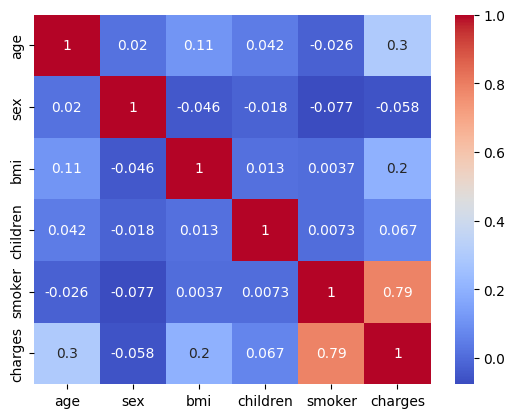

In [7]:
cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'charges']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#From the heatmap, we can see that smoking has the highest correlation with the charges response with a correlation of 0.79.
#The next highest correlations will be 0.3 for age and 0.2 for bmi.

#Low correlation for sex and children features.

## **Categorial Feature Analysis**

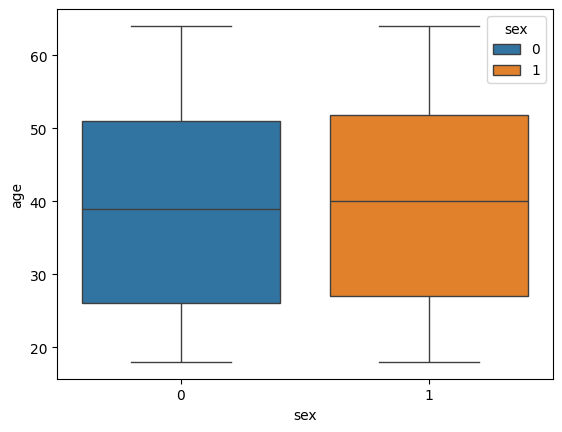

      25%   50%    75%    IQR
sex                          
0    26.0  39.0  51.00  25.00
1    27.0  40.0  51.75  24.75


In [8]:
sns.boxplot(data = df, x = 'sex' , y = 'age', hue = 'sex')
plt.show()

age_iqr_table = df.groupby('sex')['age'].describe()[['25%', '50%', '75%']]
age_iqr_table['IQR'] = age_iqr_table['75%'] - age_iqr_table['25%']
print(age_iqr_table)

##### Median ages of male vs female is almost the same (39 vs 40). IQR also almost the same (24.75 vs 25). No outliers in either gender

<Axes: xlabel='count', ylabel='sex'>

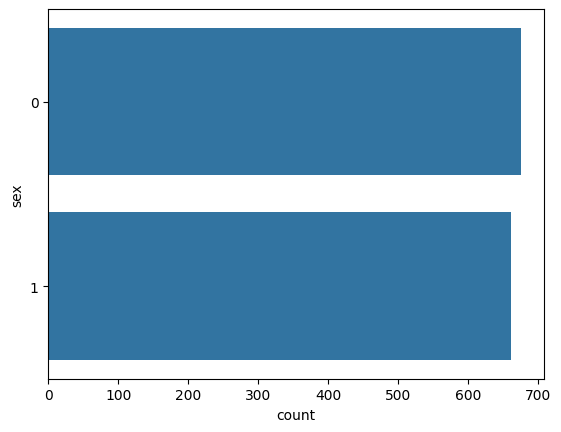

In [9]:
sns.countplot(y = df['sex']) #Roughly the same number of male and females

<Axes: xlabel='count', ylabel='smoker'>

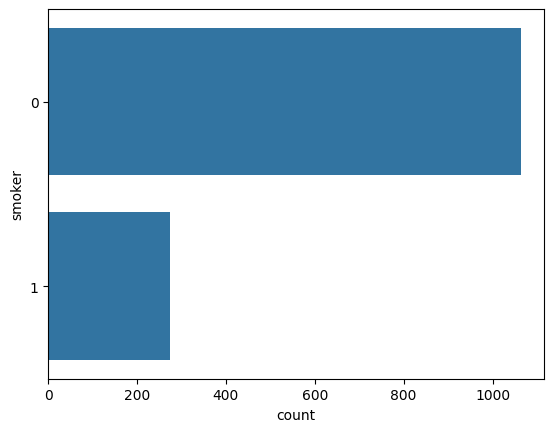

In [10]:
sns.countplot(y = df['smoker']) #Many more non smokers than smokers

<Axes: xlabel='smoker', ylabel='charges'>

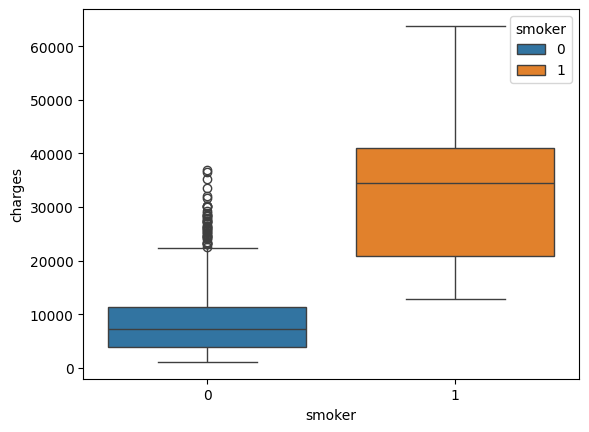

In [11]:
sns.boxplot(data=df, x = 'smoker', y = 'charges', hue = 'smoker')
#Boxplot of charges for smokers is higher than that of non smokers. Non smokers have many outliers above the upper whisker.

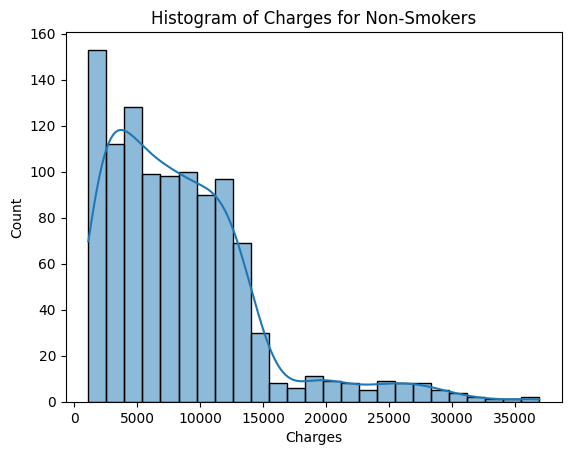

In [12]:
sns.histplot(df[df['smoker'] == 0]['charges'], kde=True)
plt.xlabel('Charges')
plt.title('Histogram of Charges for Non-Smokers')
plt.show() #Right skewed

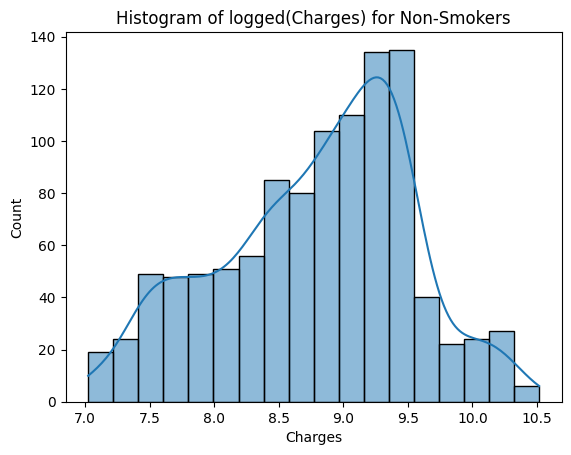

In [13]:
##Apply log
sns.histplot(np.log(df[df['smoker'] == 0]['charges']), kde=True)
plt.xlabel('Charges')
plt.title('Histogram of logged(Charges) for Non-Smokers')
plt.show() #Slightly more uniform

<Axes: xlabel='count', ylabel='region'>

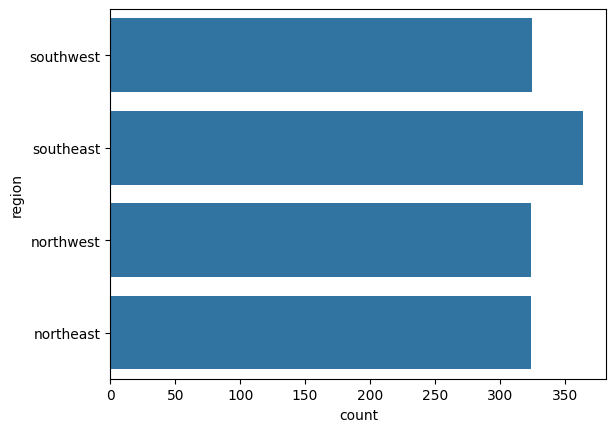

In [14]:
sns.countplot(df['region'])
#Southeast region has around ~50 more observations than the rest.

<Axes: xlabel='region', ylabel='charges'>

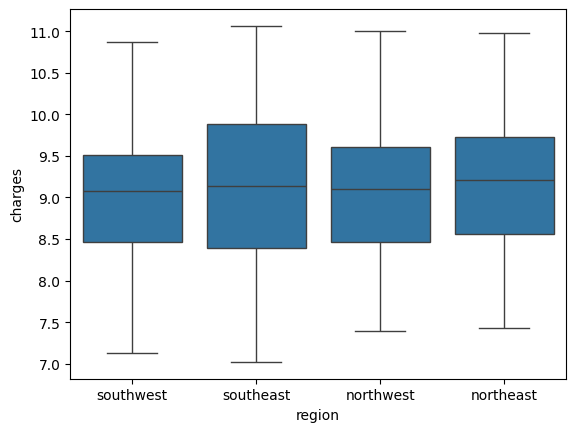

In [15]:
sns.boxplot(x = df['region'], y = np.log(df['charges'])) #No outliers after applying log to charges

<Axes: xlabel='count', ylabel='children'>

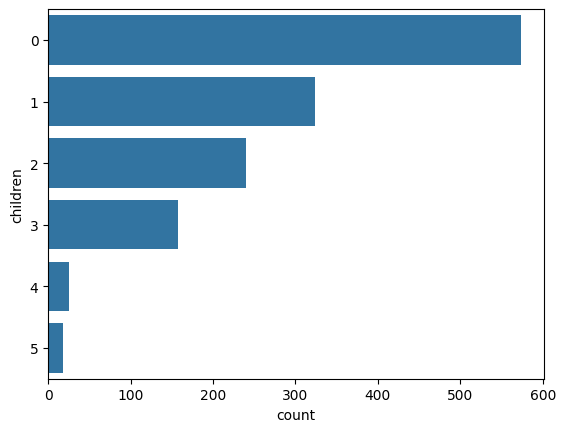

In [16]:
sns.countplot(y = df['children'])

<Axes: xlabel='children', ylabel='charges'>

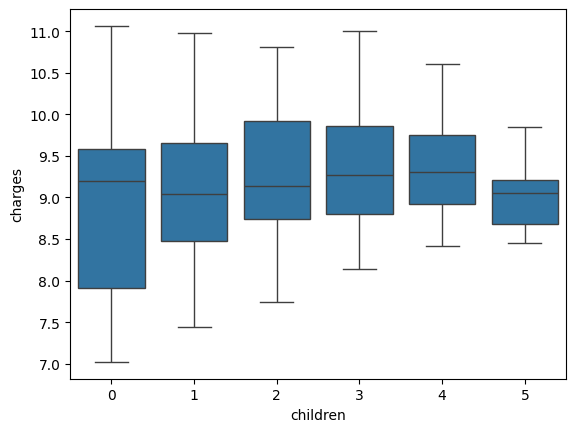

In [17]:
sns.boxplot(x = df['children'], y = np.log(df['charges']))
#Those with 5 children have a smaller IQR and median compared to those with < 5 children or less.

## **Continuous variables EDA**

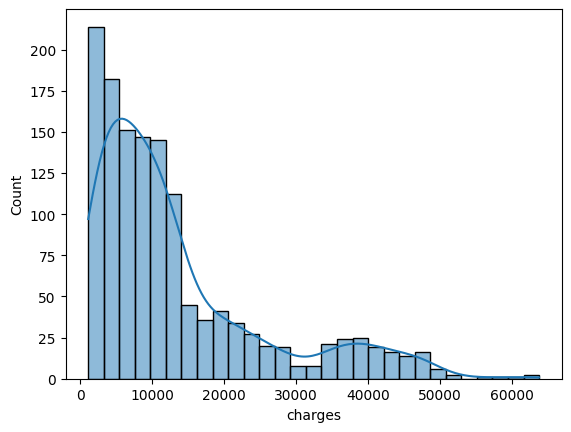

In [18]:
sns.histplot(data = df, x = 'charges', kde = True)
plt.show()

#Charges variable is not uniformally distributed.

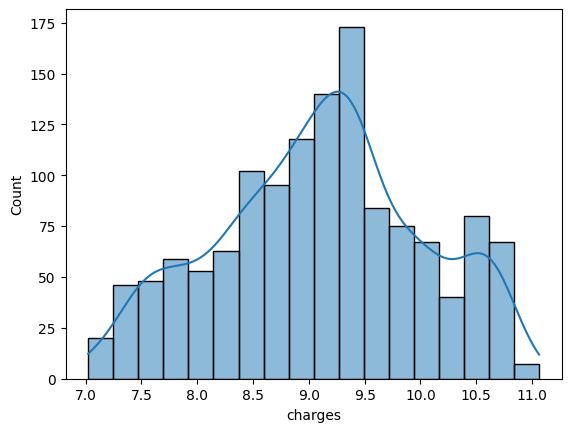

In [19]:
sns.histplot(np.log(df['charges']), kde=True)
plt.show()
#Applying log function to charges makes the histogram more normally distributed.

<Axes: xlabel='age', ylabel='Count'>

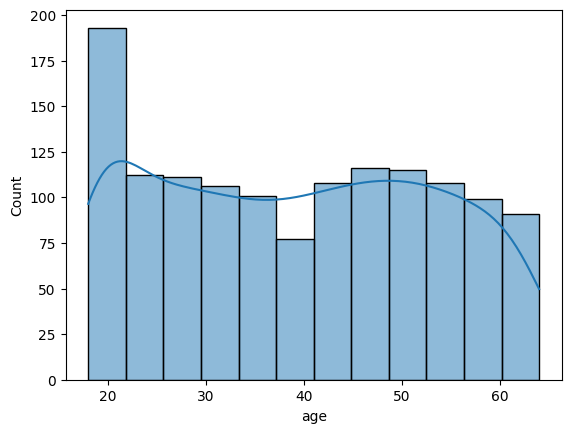

In [20]:
sns.histplot(df['age'], kde = True)

<Axes: xlabel='bmi', ylabel='Count'>

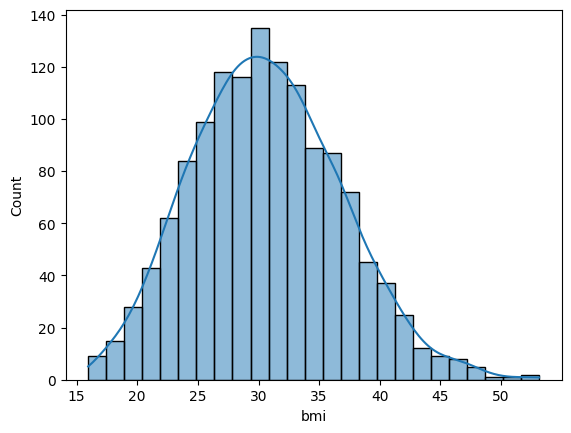

In [21]:
sns.histplot(df['bmi'], kde = True)
#BMI has very uniform distribution

<Axes: xlabel='age', ylabel='charges'>

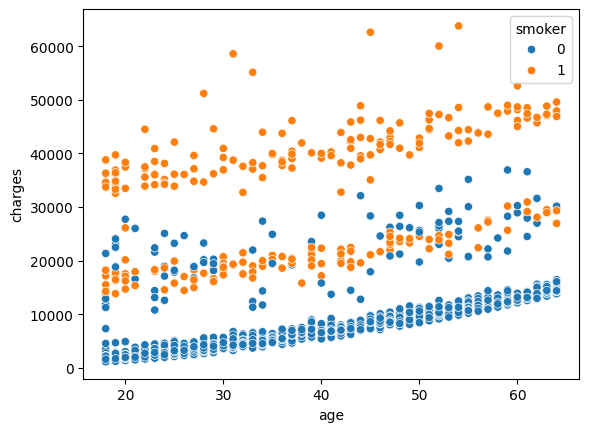

In [22]:
sns.scatterplot(x = df['age'], y = df['charges'], hue = df['smoker'])
#Charges above 30k tend to be mostly for smokers
#Chargers under 10k all non-smokers

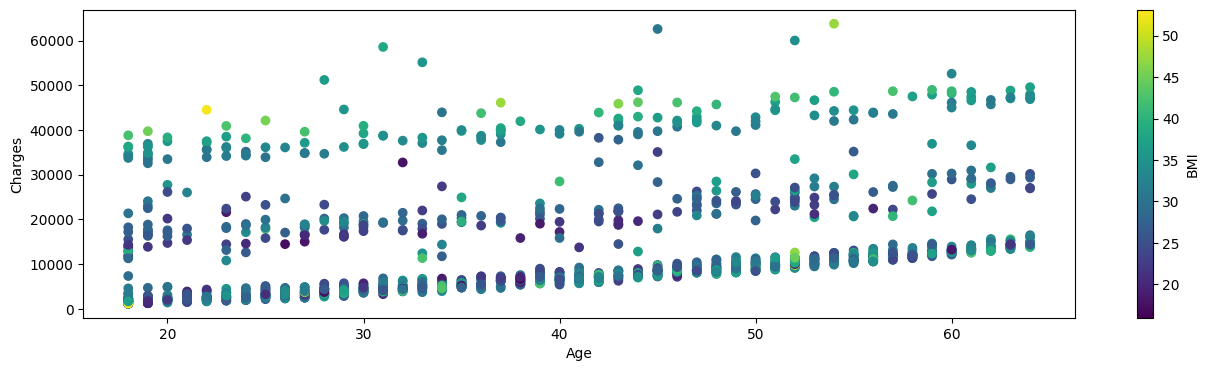

In [23]:
plt.figure(figsize=(16, 4))
plt.scatter(df['age'], df['charges'], c=df['bmi'])
plt.colorbar(label='BMI')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()

#Higher bmi tend to have higher charges

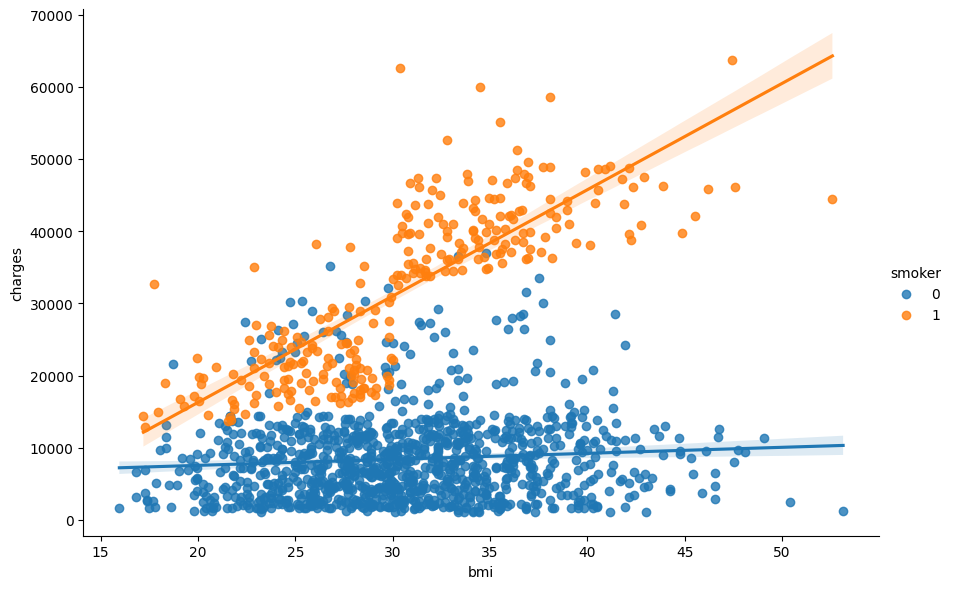

In [24]:
sns.lmplot(x='bmi', y='charges', hue='smoker', data=df, height=6, aspect=1.5)
plt.show()

#Strong positive linear correlation for smokers but weak correlation for non smokers.
#Model choice – linear regression may underfit non-smokers; tree-based models handle differing relationships automatically.

#Create bmi*smoker feature

## **Fairness Analysis**

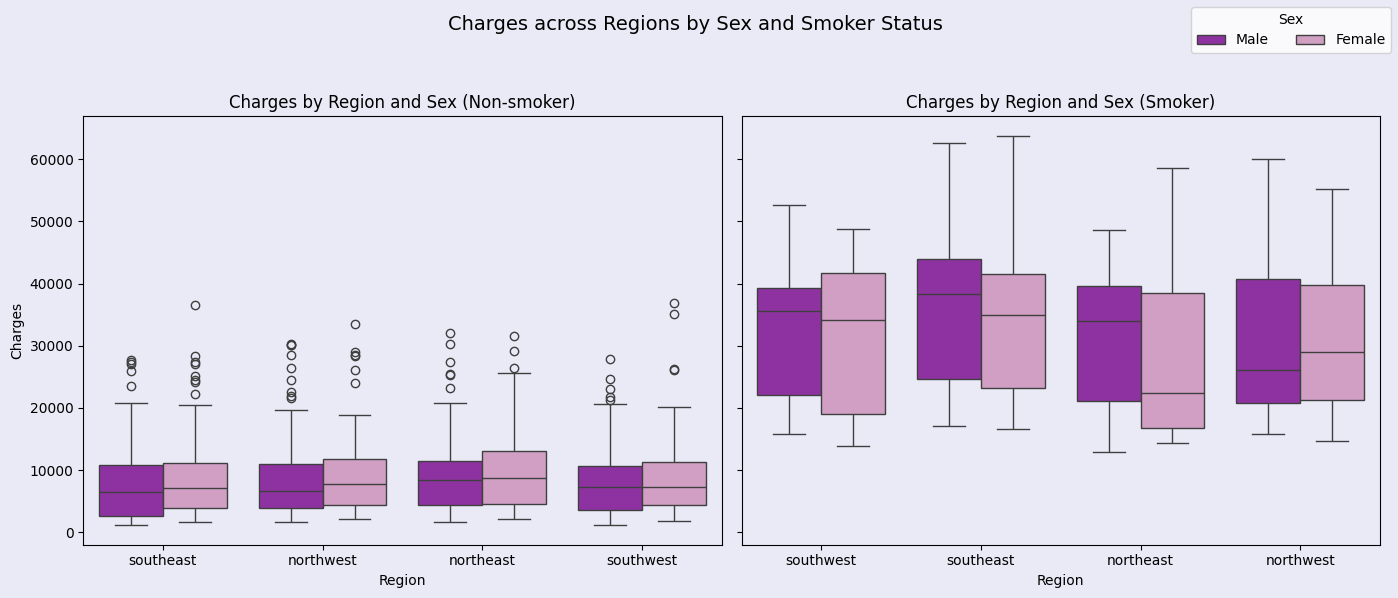

In [25]:
# Map binary back to readable labels
temp = df.copy()

temp["sex_label"] = temp["sex"].map({1: "Female", 0: "Male"})
temp["smoker_label"] = temp["smoker"].map({1: "Smoker", 0: "Non-smoker"})

# Define fixed color palette and order
palette = {"Male": "#9b1fb4", "Female": "#d897c7"}
hue_order = ["Male", "Female"]

# Plot: one panel for Non-smokers, one for Smokers
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.patch.set_facecolor('#E9EAF6')


for i, smoker_status in enumerate(["Non-smoker", "Smoker"]):
    subset = temp[temp["smoker_label"] == smoker_status]
    sns.boxplot(
        data=subset,
        x="region", y="charges", hue="sex_label",
        hue_order=hue_order,
        palette=palette,
        ax=axes[i]
    )
    axes[i].set_title(f"Charges by Region and Sex ({smoker_status})")
    axes[i].set_xlabel("Region")
    axes[i].set_ylabel("Charges" if i == 0 else "")
    axes[i].legend_.remove()
    axes[i].set_facecolor('#E9EAF6')

# One shared legend (centered on top)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Sex", loc="upper right", ncol=2)

plt.suptitle("Charges across Regions by Sex and Smoker Status", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## **Feature Engineering**

In [26]:
#Create a copy of our original df
df_copy = df.copy()

df_copy['is_female'] = df_copy['sex']
df_copy['is_smoker'] = df_copy['smoker']

df_copy = df_copy[['age', 'is_female', 'is_smoker', 'bmi', 'children', 'region', 'charges']]

#Create function to categorise bmi of each patient
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25:
        return 'Normal'
    elif 25 <= bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

#Creating more columns
#Since smoking and age variables have the highest 2 correlation with our response (charges), we create engineered columns using them, with extra column of bmi category.
df_copy['bmi_category'] = df_copy['bmi'].apply(bmi_category)
df_copy['logged_charges'] = np.log(df_copy['charges'])
df_copy['smoker_bmi'] = df_copy['is_smoker'] * df_copy['bmi']
df_copy['age_bmi'] = df_copy['age'] * df_copy['bmi']
df_copy['age_children'] = df_copy['age'] * df_copy['children']
df_copy['smoker_age'] = df_copy['is_smoker'] * df_copy['age']
df_copy['smoker_children'] = df_copy['children'] * df_copy['is_smoker']
df_copy = pd.get_dummies(df_copy, columns=['region', 'bmi_category'], drop_first=True)

In [27]:
print(df_copy.head())

   age  is_female  is_smoker     bmi  children      charges  logged_charges  \
0   19          1          1  27.900         0  16884.92400        9.734176   
1   18          0          0  33.770         1   1725.55230        7.453302   
2   28          0          0  33.000         3   4449.46200        8.400538   
3   33          0          0  22.705         0  21984.47061        9.998092   
4   32          0          0  28.880         0   3866.85520        8.260197   

   smoker_bmi  age_bmi  age_children  smoker_age  smoker_children  \
0        27.9  530.100             0          19                0   
1         0.0  607.860            18           0                0   
2         0.0  924.000            84           0                0   
3         0.0  749.265             0           0                0   
4         0.0  924.160             0           0                0   

   region_northwest  region_southeast  region_southwest  bmi_category_Obese  \
0             False            

## **Modelling**

In [28]:
#Create X and y variable to use for train-test split
y = df_copy['logged_charges']
X = df_copy.drop(columns=['charges', 'logged_charges'])
print(X.dtypes)
#All are either int / float / boolean types, able to be used in Linear regression model

age                           int64
is_female                     int64
is_smoker                     int64
bmi                         float64
children                      int64
smoker_bmi                  float64
age_bmi                     float64
age_children                  int64
smoker_age                    int64
smoker_children               int64
region_northwest               bool
region_southeast               bool
region_southwest               bool
bmi_category_Obese             bool
bmi_category_Overweight        bool
bmi_category_Underweight       bool
dtype: object


### Train test Split

In [29]:
#Create 80-20 train-test split ratio
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### K-Folds

In [30]:
#5-fold CV within the 80% training split
kf = KFold(n_splits=5, shuffle=True, random_state=42)

### Baseline Model: Linear Regression


Validation Performance (20% holdout) - Linear Regression:
R² (logged-scale): 0.8723
Adjusted R² (logged-scale): 0.8642
MAE (logged-scale): 0.2023
RMSE (logged-scale): 0.3442


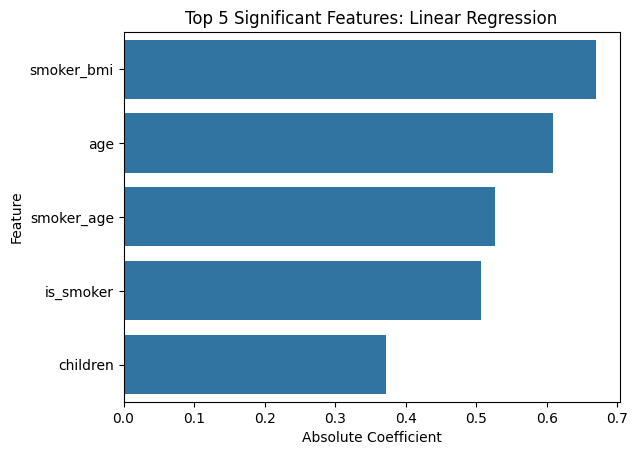

In [31]:
lr_full_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

r2_scores = cross_val_score(lr_full_pipeline, X_train, y_train, cv=kf, scoring='r2')
mae_scores = -cross_val_score(lr_full_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
mse_scores = -cross_val_score(lr_full_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

lr_full_pipeline.fit(X_train, y_train)

# Validation
y_pred_val = lr_full_pipeline.predict(X_val)

r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
n = X_val.shape[0]
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nValidation Performance (20% holdout) - Linear Regression:")
print(f"R² (logged-scale): {r2:.4f}")
print(f"Adjusted R² (logged-scale): {adj_r2:.4f}")
print(f"MAE (logged-scale): {mae:.4f}")
print(f"RMSE (logged-scale): {np.sqrt(mse):.4f}")

# Feature importance
lr_model = lr_full_pipeline.named_steps['lr']
coef_imp = pd.Series(np.abs(lr_model.coef_), index=X.columns).sort_values(ascending=False).head(5)
sns.barplot(x=coef_imp, y=coef_imp.index)
plt.xlabel('Absolute Coefficient')
plt.ylabel("Feature")
plt.title("Top 5 Significant Features: Linear Regression")
plt.show()

## Advanced Models

#### Gradient Boosting

In [32]:
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingRegressor(random_state=42))
])

#Parameter distributions for random search
param_dist = {
    'gb__n_estimators': [100, 200, 300, 500, 800],
    'gb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'gb__max_depth': [3, 4, 5, 6],
    'gb__min_samples_split': [2, 5, 10],
    'gb__min_samples_leaf': [1, 2, 4],
    'gb__subsample': [0.6, 0.8, 1.0],
    'gb__max_features': ['sqrt', 'log2', None]
}

gb_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    scoring='r2',
    cv=kf,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

#Fit random search on the training data (80%)
gb_search.fit(X_train, y_train)

print("Best parameters from 5-fold CV on training data:")
print(gb_search.best_params_)
print(f"Best mean CV R²: {gb_search.best_score_:.4f}")

#Refit best model on full 80% training set
best_gb = gb_search.best_estimator_
best_gb.fit(X_train, y_train)

#Evaluate on held-out 20% validation set
y_pred_val = best_gb.predict(X_val)

r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
n = X_val.shape[0]
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nValidation Performance (20% holdout) - Gradient Boosting:")
print(f"R² (logged-scale): {r2:.4f}")
print(f"Adjusted R² (logged-scale): {adj_r2:.4f}")
print(f"MAE (logged-scale): {mae:.4f}")
print(f"RMSE (logged-scale): {np.sqrt(mse):.4f}")



Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters from 5-fold CV on training data:
{'gb__subsample': 0.6, 'gb__n_estimators': 500, 'gb__min_samples_split': 5, 'gb__min_samples_leaf': 2, 'gb__max_features': 'sqrt', 'gb__max_depth': 4, 'gb__learning_rate': 0.01}
Best mean CV R²: 0.8185

Validation Performance (20% holdout) - Gradient Boosting:
R² (logged-scale): 0.8806
Adjusted R² (logged-scale): 0.8730
MAE (logged-scale): 0.1900
RMSE (logged-scale): 0.3329


#### Random Forest

In [33]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()), 
    ('rf', RandomForestRegressor(random_state=42))
])

#Parameter distributions
rf_param_dist = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 4, 6, 8],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None],
    'rf__bootstrap': [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring='r2',
    cv=kf,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

#Fit random search on 80% training data
rf_search.fit(X_train, y_train)

#Best parameters and mean CV R²
print("RF Best Parameters (from 5-fold CV):")
print(rf_search.best_params_)
print(f"Best mean CV R²: {rf_search.best_score_:.4f}")

#Refit best model on full 80% training set
best_rf = rf_search.best_estimator_
best_rf.fit(X_train, y_train)

#Evaluate on 20% validation set
y_pred_val = best_rf.predict(X_val)

r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
n = X_val.shape[0]
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nValidation Performance (20% holdout) - Random Forest:")
print(f"R² (logged-scale): {r2:.4f}")
print(f"Adjusted R² (logged-scale): {adj_r2:.4f}")
print(f"MAE (logged-scale): {mae:.4f}")
print(f"RMSE (logged-scale): {np.sqrt(mse):.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
RF Best Parameters (from 5-fold CV):
{'rf__n_estimators': 500, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 4, 'rf__max_features': 'log2', 'rf__max_depth': None, 'rf__bootstrap': True}
Best mean CV R²: 0.8144

Validation Performance (20% holdout) - Random Forest:
R² (logged-scale): 0.8764
Adjusted R² (logged-scale): 0.8685
MAE (logged-scale): 0.1901
RMSE (logged-scale): 0.3387


#### SVR (Support Vector Regression)

In [34]:
svr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

#Parameter distributions
svr_param_dist = {
    'svr__C': [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.2, 0.5],
    'svr__kernel': ['linear', 'rbf', 'poly'],
    'svr__gamma': ['scale', 'auto']
}

#5-Fold CV on 80% training data
kf = KFold(n_splits=5, shuffle=True, random_state=42)

svr_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=svr_param_dist,
    n_iter=30,
    scoring='r2',
    cv=kf,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

#Fit random search on 80% training data
svr_search.fit(X_train, y_train)

print("SVR Best Parameters (from 5-fold CV):")
print(svr_search.best_params_)
print(f"Best mean CV R²: {svr_search.best_score_:.4f}")

#Refit best model on full 80% training set
best_svr = svr_search.best_estimator_
best_svr.fit(X_train, y_train)

y_pred_val = best_svr.predict(X_val)

r2 = r2_score(y_val, y_pred_val)
mae = mean_absolute_error(y_val, y_pred_val)
mse = mean_squared_error(y_val, y_pred_val)
n = X_val.shape[0]
p = X_val.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("\nValidation Performance (20% holdout) - SVR:")
print(f"R² (logged-scale): {r2:.4f}")
print(f"Adjusted R² (logged-scale): {adj_r2:.4f}")
print(f"MAE (logged-scale): {mae:.4f}")
print(f"RMSE (logged-scale): {np.sqrt(mse):.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
SVR Best Parameters (from 5-fold CV):
{'svr__kernel': 'linear', 'svr__gamma': 'scale', 'svr__epsilon': 0.2, 'svr__C': 0.1}
Best mean CV R²: 0.8132

Validation Performance (20% holdout) - SVR:
R² (logged-scale): 0.8729
Adjusted R² (logged-scale): 0.8648
MAE (logged-scale): 0.1811
RMSE (logged-scale): 0.3435


## **Comparison of Metrics across all models**

In [35]:
# 5-Fold CV + original-scale metrics
def compute_cv_metrics_dual(model_pipeline, X_train, y_train, cv):
    r2_list_log, adj_r2_list_log, mae_list_log, mse_list_log = [], [], [], []
    r2_list_orig, adj_r2_list_orig, mae_list_orig, mse_list_orig = [], [], [], []

    n, p = X_train.shape

    for train_idx, test_idx in cv.split(X_train):
        X_tr, X_te = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_tr, y_te = y_train.iloc[train_idx], y_train.iloc[test_idx]

        model = clone(model_pipeline)
        model.fit(X_tr, y_tr)
        y_pred_log = model.predict(X_te)

        # Logged metrics
        r2_log = r2_score(y_te, y_pred_log)
        adj_r2_log = 1 - (1 - r2_log) * (len(y_te) - 1) / (len(y_te) - p - 1)
        mae_log = mean_absolute_error(y_te, y_pred_log)
        mse_log = mean_squared_error(y_te, y_pred_log)

        r2_list_log.append(r2_log)
        adj_r2_list_log.append(adj_r2_log)
        mae_list_log.append(mae_log)
        mse_list_log.append(mse_log)

        # Original-scale metrics
        y_te_orig = np.exp(y_te)
        y_pred_orig = np.exp(y_pred_log)
        r2_orig = r2_score(y_te_orig, y_pred_orig)
        adj_r2_orig = 1 - (1 - r2_orig) * (len(y_te_orig) - 1) / (len(y_te_orig) - p - 1)
        mae_orig = mean_absolute_error(y_te_orig, y_pred_orig)
        mse_orig = mean_squared_error(y_te_orig, y_pred_orig)

        r2_list_orig.append(r2_orig)
        adj_r2_list_orig.append(adj_r2_orig)
        mae_list_orig.append(mae_orig)
        mse_list_orig.append(mse_orig)

    df_log = pd.Series({
        "R² (logged)": np.mean(r2_list_log),
        "Adjusted R² (logged)": np.mean(adj_r2_list_log),
        "MAE (logged)": np.mean(mae_list_log),
        "RMSE (logged)": np.sqrt(np.mean(mse_list_log))
    })

    df_orig = pd.Series({
        "R² (orig)": np.mean(r2_list_orig),
        "Adjusted R² (orig)": np.mean(adj_r2_list_orig),
        "MAE (orig)": np.mean(mae_list_orig),
        "RMSE (orig)": np.sqrt(np.mean(mse_list_orig))
    })

    return pd.concat([df_log, df_orig])

# Function for hold-out validation metrics
def compute_validation_metrics_dual(model_pipeline, X_val, y_val):
    y_pred_log = model_pipeline.predict(X_val)

    # Logged metrics
    n_features = X_val.shape[1]
    r2_log = r2_score(y_val, y_pred_log)
    adj_r2_log = 1 - (1 - r2_log) * (len(y_val) - 1) / (len(y_val) - n_features - 1)
    mae_log = mean_absolute_error(y_val, y_pred_log)
    mse_log = mean_squared_error(y_val, y_pred_log)

    # Original-scale metrics
    y_val_orig = np.exp(y_val)
    y_pred_orig = np.exp(y_pred_log)
    r2_orig = r2_score(y_val_orig, y_pred_orig)
    adj_r2_orig = 1 - (1 - r2_orig) * (len(y_val_orig) - 1) / (len(y_val_orig) - n_features - 1)
    mae_orig = mean_absolute_error(y_val_orig, y_pred_orig)
    mse_orig = mean_squared_error(y_val_orig, y_pred_orig)

    df_log = pd.Series({
        "R² (logged-scale)": r2_log,
        "Adjusted R² (logged-scale)": adj_r2_log,
        "MAE (logged-scale)": mae_log,
        "RMSE (logged-scale)": np.sqrt(mse_log)
    })

    df_orig = pd.Series({
        "R² (orig-scale)": r2_orig,
        "Adjusted R² (orig-scale)": adj_r2_orig,
        "MAE (orig-scale)": mae_orig,
        "RMSE (orig-scale)": np.sqrt(mse_orig)
    })

    return pd.concat([df_log, df_orig])


# Compute CV metrics
cv_metrics = pd.DataFrame({
    "Linear Regression": compute_cv_metrics_dual(lr_full_pipeline, X_train, y_train, kf),
    "Gradient Boosting": compute_cv_metrics_dual(best_gb, X_train, y_train, kf),
    "Random Forest": compute_cv_metrics_dual(best_rf, X_train, y_train, kf),
    "SVR": compute_cv_metrics_dual(best_svr, X_train, y_train, kf)
}).T

print("Mean metrics (5-fold CV) - logged and original scale:")
print(cv_metrics.round(4))

# Compute hold-out validation metrics
val_metrics = pd.DataFrame({
    "Linear Regression": compute_validation_metrics_dual(lr_full_pipeline, X_val, y_val),
    "Gradient Boosting": compute_validation_metrics_dual(best_gb, X_val, y_val),
    "Random Forest": compute_validation_metrics_dual(best_rf, X_val, y_val),
    "SVR": compute_validation_metrics_dual(best_svr, X_val, y_val)
}).T

print("\nValidation metrics (20% hold-out) - logged and original scale:")
print(val_metrics.round(4))


Mean metrics (5-fold CV) - logged and original scale:
                   R² (logged)  Adjusted R² (logged)  MAE (logged)  \
Linear Regression       0.8160                0.8011        0.2114   
Gradient Boosting       0.8185                0.8038        0.2014   
Random Forest           0.8144                0.7994        0.2028   
SVR                     0.8132                0.7980        0.1930   

                   RMSE (logged)  R² (orig)  Adjusted R² (orig)  MAE (orig)  \
Linear Regression         0.3864     0.8050              0.7892   2618.7639   
Gradient Boosting         0.3831     0.8434              0.8306   2063.0686   
Random Forest             0.3876     0.8439              0.8312   2049.7012   
SVR                       0.3893     0.8108              0.7954   2520.5965   

                   RMSE (orig)  
Linear Regression    5120.5884  
Gradient Boosting    4587.8166  
Random Forest        4579.4882  
SVR                  5054.5898  

Validation metrics (20% hold-out)

### Comparison plot of Adjusted R^2 and RMSE metrics (original-scale) across models

###

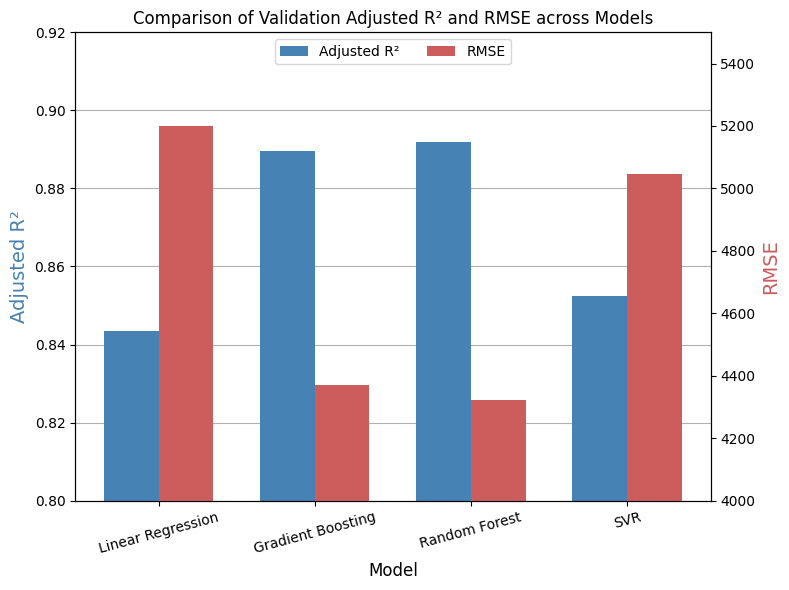

In [36]:
metrics_data = {
    'Model': ['Linear Regression', 'Gradient Boosting', 'Random Forest', 'SVR'],
    'Adjusted R²': [0.8434, 0.8895, 0.8918, 0.8525],
    'RMSE': [5200.9495, 4369.3813, 4323.9299, 5047.2599]
}
metrics_df = pd.DataFrame(metrics_data)

# Positions
x = np.arange(len(metrics_df['Model']))
width = 0.35

fig, ax1 = plt.subplots(figsize=(8,6))
ax2 = ax1.twinx()

# Grids and Bars
ax1.grid(True, axis='y', linestyle='-', zorder=0)
ax2.grid(False) 
bars1 = ax1.bar(x - width/2, metrics_df['Adjusted R²'], width, color='steelblue', label='Adjusted R²', zorder = 2)
bars2 = ax2.bar(x + width/2, metrics_df['RMSE'], width, color='indianred', label='RMSE', zorder = 2)

# Labels
ax1.set_xlabel('Model', fontsize = 12)
ax1.set_ylabel('Adjusted R²', color='steelblue', fontsize = 14)
ax2.set_ylabel('RMSE', color='indianred', fontsize = 14)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Model'], rotation=15)
ax1.set_ylim(0.8, 0.92)
ax2.set_ylim(4000, 5500)
ax1.set_title('Comparison of Validation Adjusted R² and RMSE across Models')

# Legend
lines, labels = [], []
for ax in [ax1, ax2]:
    line, label = ax.get_legend_handles_labels()
    lines += line
    labels += label
ax1.legend(lines, labels, loc='upper center', ncol=2, frameon=True)


plt.tight_layout()
plt.show()

### Top 5 most important features in Random Forest Model

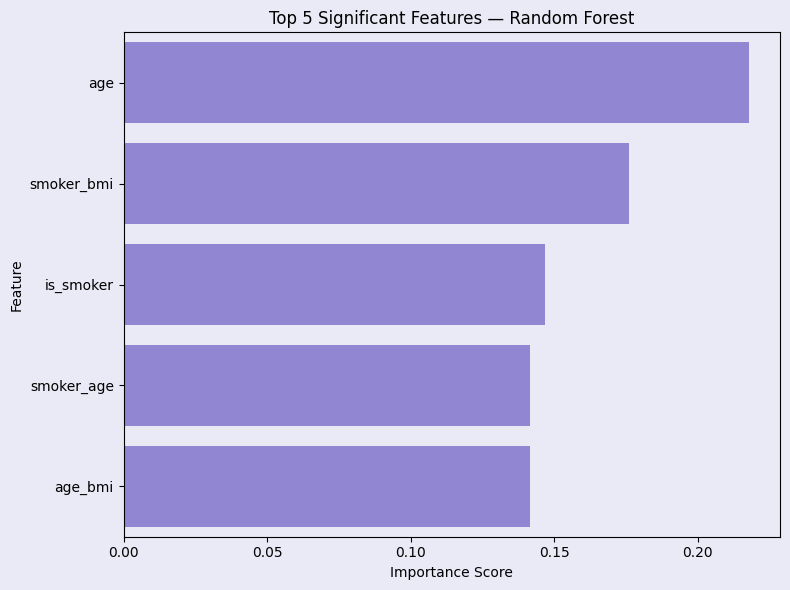

In [37]:
# Get feature importances from Random Forest
rf_importances = best_rf.named_steps['rf'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 5 features
plt.figure(figsize=(8, 6), facecolor='#E9EAF6')

sns.barplot(data=feat_imp.head(5), x='Importance', y='Feature', color = '#8779DD')
plt.gca().set_facecolor('#E9EAF6')
plt.title("Top 5 Significant Features — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Bar plot of average charges against age, smoking status and BMI.

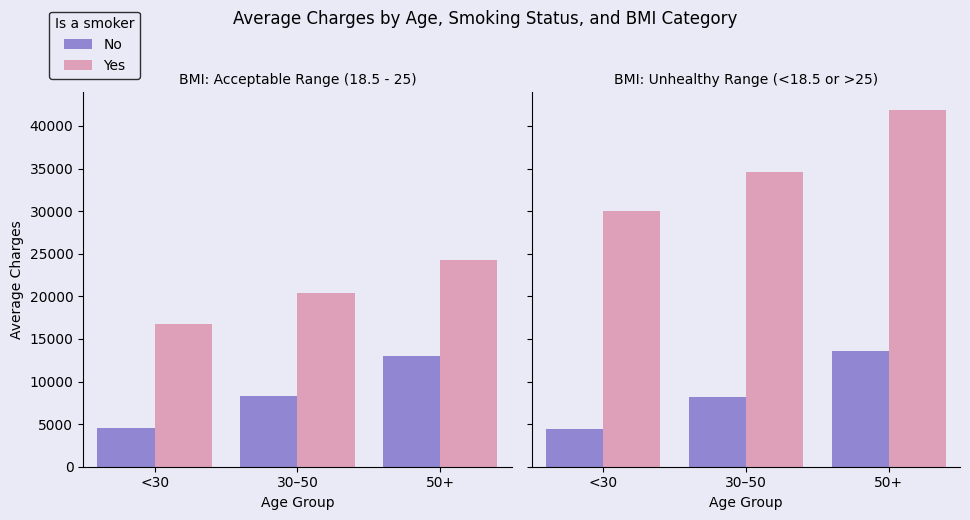

In [38]:
def combine_bmi(row):
    if row['bmi_category_Underweight'] == 1 or row['bmi_category_Overweight'] == 1 or row['bmi_category_Obese'] == 1:
        return 'Unhealthy Range (<18.5 or >25)'
    else:
        return 'Acceptable Range (18.5 - 25)'

df_copy['BMICategoryCombined'] = df_copy.apply(combine_bmi, axis=1)

# Create age groups
df_copy['AgeGroup'] = pd.cut(df_copy['age'], bins=[0, 30, 50, 80], labels=['<30', '30–50', '50+'])

# Compute mean charges per group
group_means = (
    df_copy.groupby(['AgeGroup', 'is_smoker', 'BMICategoryCombined'], observed=True)['charges']
    .mean()
    .reset_index()
)

palette = ["#8779DD", "#E995B7"]

g = sns.catplot(
    data=group_means.replace({'is_smoker': {0: 'No', 1: 'Yes'}}),
    x='AgeGroup',
    y='charges',
    hue='is_smoker',
    col='BMICategoryCombined',
    kind='bar',
    height=5,
    aspect=0.9,
    palette=palette,
    errorbar=None
)

# Figure styling
g.figure.set_facecolor("#E9EAF6")
for ax in g.axes.flatten():
    ax.set_facecolor("#E9EAF6")  
    
g.set_axis_labels("Age Group", "Average Charges")
g.set_titles("BMI: {col_name}")
plt.suptitle("Average Charges by Age, Smoking Status, and BMI Category", y=1.03)

# Legend styling
g._legend.set_bbox_to_anchor((0.15, 0.95))
g._legend.set_frame_on(True)
g._legend.get_frame().set_edgecolor('black')
g._legend.set_title("Is a smoker")
g._legend.get_frame().set_facecolor("#E9EAF6")

plt.tight_layout()
plt.show()

## **Conclusion**
#### We see that Random Forest Model gives the best metrics of Adjusted R^2 = 0.8918 and RMSE = 4323.8957.
#### Comparing with our baseline model of Linear Regression (Adjusted R^2 = 0.8434, MSE = 5200.9495), we see that our Random Forest model reduces the typical prediction error by roughly 17%, capturing more of the variance in charges and improving predictive accuracy over the linear baseline.